In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
df = pd.read_csv('../data/utility_leakage.csv')

In [2]:
df.head()

,attack,dataset,rag,llm,ULR,ASR,ARE,CLF,SS,answer_relevancy,answer_infodepth,faithfulness
0,WBTQ,FiQA,vanilla,Qwen3-32B,258,113,865,0.8391,0.7546,0.8058,0.8045,0.7708
1,WBTQ,FiQA,+RR,Qwen3-32B,204,109,840,0.8907,0.7401,0.8019,0.8045,0.7490
2,WBTQ,FiQA,+RR+RW,Qwen3-32B,188,100,891,0.8488,0.7456,0.8353,0.8047,0.7588
3,WBTQ,FiQA,+RR+RW+Sum,Qwen3-32B,88,56,894,0.5860,0.7244,0.8218,0.7922,0.6107
4,WBTQ,FiQA,vanilla,o4-mini,83,38,865,0.8505,0.6452,0.7784,0.7763,0.6895


In [3]:
df["ASR"] = df["ASR"] /200
df["ULR"] = df["ULR"] /1000
df["ARE"] = df["ARE"] /1000

In [4]:
# 数据集名称列表
datasets = ['FiQA', 'NFcorpus', 'SciFact']
LLMs =['DeepSeek-V3', 'Gemma-3-27B', 'Kimi-K2', 'Qwen2.5-14B', 'Qwen3-32B', 'o4-mini']
metrics = ['ASR', 'ULR', 'ARE', 'CLF', 'SS', 'anwser_relevancy', 'anwser_infodepth', 'faithfulness']

df_split_by_datasets = [df[df['dataset'] == dataset] for dataset in datasets]

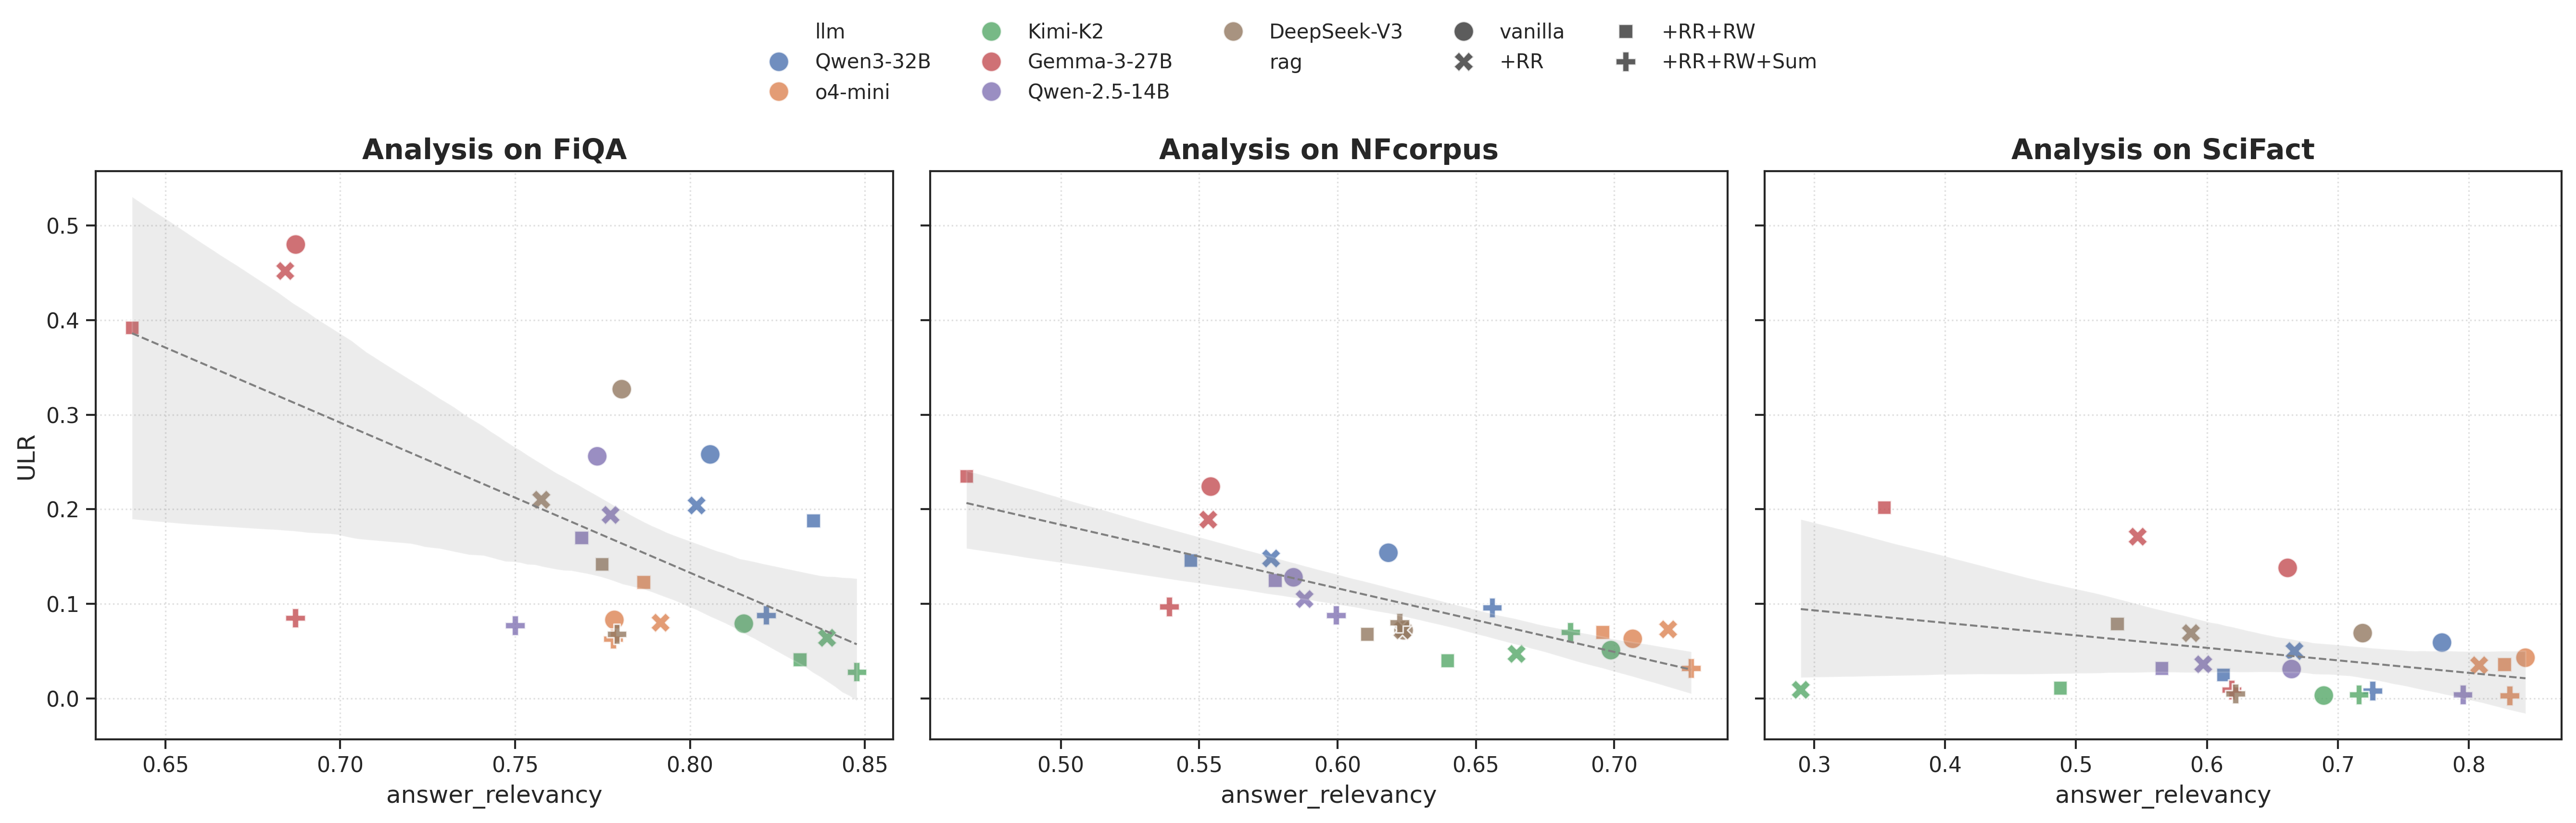

In [6]:
sns.set_context("paper", font_scale=1.2)
sns.set_style("ticks")

# 3. 创建画布：1行3列
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, dpi=300)


for i, ax in enumerate(axes):
    # --- 这里替换为你真实的数据抽取逻辑 ---
    # 模拟一份数据
    data = pd.DataFrame({
        'faithfulness': df_split_by_datasets[i]["faithfulness"],
        'answer_relevancy': df_split_by_datasets[i]["answer_relevancy"],
        'info_depth': df_split_by_datasets[i]["answer_infodepth"],
        'ASR':  df_split_by_datasets[i]["ASR"],
        'ULR':  df_split_by_datasets[i]["ULR"],
        'ARE':  df_split_by_datasets[i]["ARE"],
        'CLF':  df_split_by_datasets[i]["CLF"],
        'SS':   df_split_by_datasets[i]["SS"],
        'llm': df_split_by_datasets[i]["llm"],
        'rag': df_split_by_datasets[i]["rag"]
    })
    
    # 绘制散点图
    # hue: 区分模型颜色, style: 区分策略形状
    sns.scatterplot(data=data, x='answer_relevancy', y='ULR', 
                    hue='llm', style='rag', 
                    s=100, ax=ax, palette='deep', alpha=0.8, edgecolor='w')
    
    # 绘制线性回归趋势线 (反映正负相关性)
    sns.regplot(data=data, x='answer_relevancy', y='ULR', 
                scatter=False, ax=ax, color='gray', line_kws={"ls":"--", "lw":1})

    # 子图细节优化
    ax.set_title(f'Analysis on {datasets[i]}', fontsize=14, fontweight='bold')
    ax.set_xlabel('answer_relevancy', fontsize=12)
    if i == 0:
        ax.set_ylabel('ULR', fontsize=12)
    
    ax.grid(True, linestyle=':', alpha=0.6)

# 4. 合并图例
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), 
           ncol=5, frameon=False, fontsize=10)

# 移除原始子图内部图例
for ax in axes:
    ax.get_legend().remove()

plt.tight_layout()
# plt.savefig('scatter_comparison.pdf', bbox_inches='tight')
plt.show()

In [28]:
from scipy.stats import pearsonr

# 计算 Faithfulness 和 ULR 的相关性及显著性
r_val, p_val = pearsonr(df['faithfulness'], df['ULR'])
print(f"Correlation: {r_val:.3f}, p-value: {p_val:.3e}")
# 如果 p < 0.05，你的发现才算“站住了”

Correlation: 0.515, p-value: 3.687e-06


In [ ]:
def plot_multi_metric_matrix(full_df):
    # 选择你想展示的因变量指标列
    metrics = ['faithfulness', 'anwser_relevancy', 'anwser_infodepth', 'SS', 'ULR', 'ASR', 'ARE', 'CLF']
    
    # 使用 seaborn 的 PairGrid
    g = sns.PairGrid(full_df, vars=metrics, hue='rag', palette='viridis', diag_sharey=False)
    
    # 上三角：绘制散点图和回归线
    g.map_upper(sns.regplot, scatter_kws={'alpha':0.3, 's':10}, line_kws={'lw':1, 'ls':'--'})
    
    # 下三角：绘制密度图 (避免数据点太多导致混乱)
    g.map_lower(sns.kdeplot, alpha=0.7)
    
    # 对角线：绘制单指标分布
    g.map_diag(sns.kdeplot, lw=2, fill=True)
    
    # 美化
    g.add_legend(title="Experimental Settings")
    for ax in g.axes.flatten():
        ax.tick_params(labelsize=8)
    
    plt.show()
plot_multi_metric_matrix(df[df['dataset']=='FiQA'])

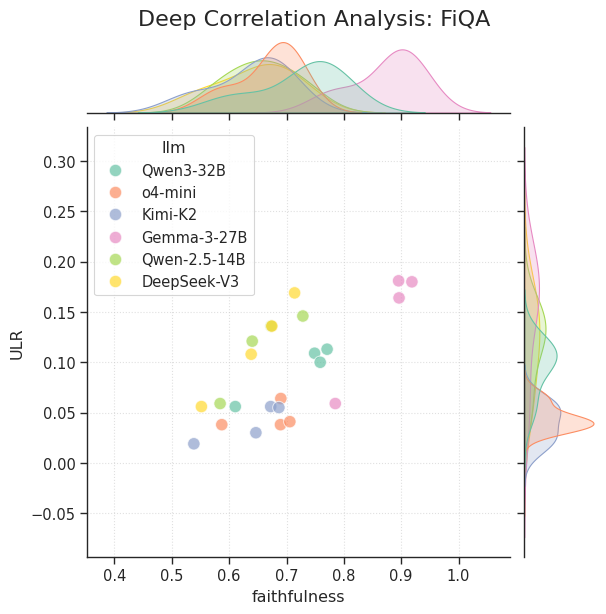

In [30]:
# 示例：针对某一个数据集进行深度分析
def plot_joint_analysis(dataset_df, ds_name):
    g = sns.jointplot(data=dataset_df, x='faithfulness', y='ULR', 
                      hue='llm', kind='scatter', alpha=0.7, s=80,
                      palette='Set2', marginal_kws=dict(fill=True))
    
    g.fig.suptitle(f'Deep Correlation Analysis: {ds_name}', y=1.02, size=16)
    g.ax_joint.grid(True, linestyle=':', alpha=0.6)
    plt.show()

plot_joint_analysis(df[df['dataset']=='FiQA'], 'FiQA')
# plot_joint_analysis(df[df['dataset']=='NFcorpus'], 'NFcorpus')
# plot_joint_analysis(df[df['dataset']=='SciFact'], 'SciFact')